# Predictive maintenance model to forecast failures in Bosch production lines

**Load Data**

In [ ]:
df = pd.read_csv('/content/synthetic_bosch_complex.csv')
df['test_time'] = pd.to_datetime(df['test_time'], errors='coerce')
df['test_hour'] = df['test_time'].dt.hour
df['test_day'] = df['test_time'].dt.dayofweek
df.drop(columns=['test_time'], inplace=True)
df = pd.get_dummies(df, columns=['station', 'product_type', 'shift'], drop_first=True)
df.fillna(df.median(), inplace=True)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.info())
print(df.describe())

missing = df.isnull().sum()
print("Missing values:\n", missing[missing > 0])

plt.figure(figsize=(6,4))
sns.countplot(x='Response', data=df)
plt.title('Response Distribution (Target Variable)')
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()


**Split & Balance Data**

**Logistic Regression**

LR Report
               precision    recall  f1-score   support

           0       0.90      0.80      0.85      1790
           1       0.14      0.27      0.18       210

    accuracy                           0.74      2000
   macro avg       0.52      0.53      0.51      2000
weighted avg       0.82      0.74      0.78      2000

ROC AUC: 0.562466081404629


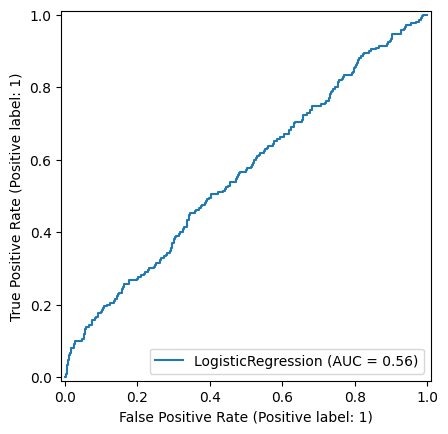

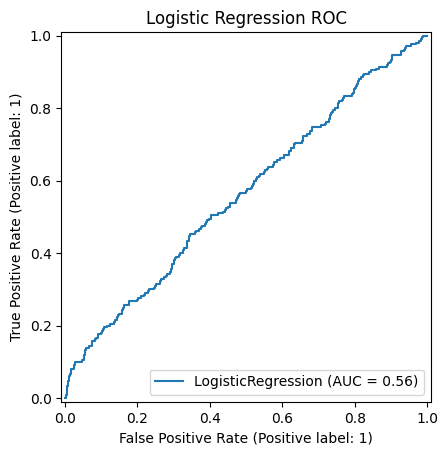

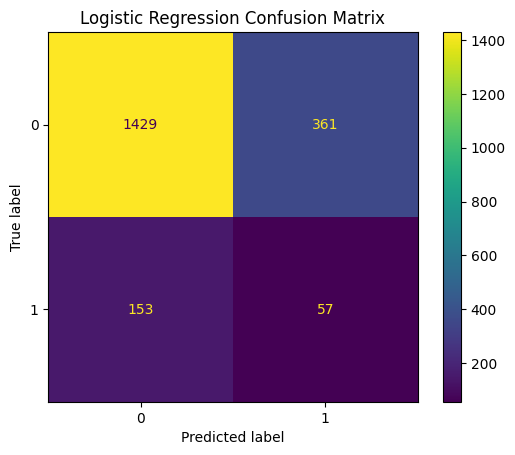

In [ ]:
param_lr = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_lr, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train_bal)
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
print("LR Report\n", classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:,1]))
RocCurveDisplay.from_estimator(best_lr, X_test_scaled, y_test).plot()
plt.title("Logistic Regression ROC")
plt.show()
ConfusionMatrixDisplay.from_estimator(best_lr, X_test_scaled, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

**KNN**

KNN Report
               precision    recall  f1-score   support

           0       0.90      0.52      0.66      1790
           1       0.11      0.53      0.19       210

    accuracy                           0.52      2000
   macro avg       0.51      0.53      0.43      2000
weighted avg       0.82      0.52      0.61      2000

ROC AUC: 0.5350571960627827


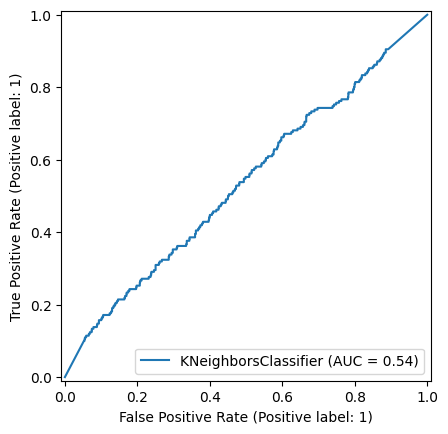

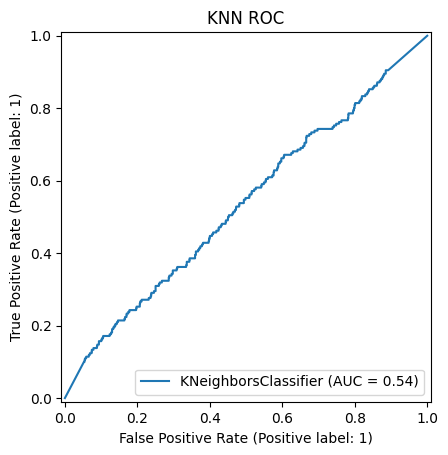

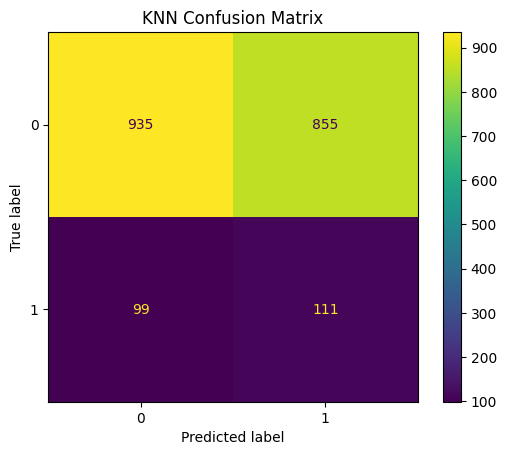

In [ ]:
param_knn = {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance'], 'p': [1, 2]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5, scoring='roc_auc', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train_bal)
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
print("KNN Report\n", classification_report(y_test, y_pred_knn))
print("ROC AUC:", roc_auc_score(y_test, best_knn.predict_proba(X_test_scaled)[:,1]))
RocCurveDisplay.from_estimator(best_knn, X_test_scaled, y_test).plot()
plt.title("KNN ROC")
plt.show()
ConfusionMatrixDisplay.from_estimator(best_knn, X_test_scaled, y_test)
plt.title("KNN Confusion Matrix")
plt.show()

**Random Forest**

Random Forest Report
               precision    recall  f1-score   support

           0       0.90      0.96      0.93      1790
           1       0.25      0.13      0.17       210

    accuracy                           0.87      2000
   macro avg       0.58      0.54      0.55      2000
weighted avg       0.84      0.87      0.85      2000

ROC AUC: 0.6382362330407023


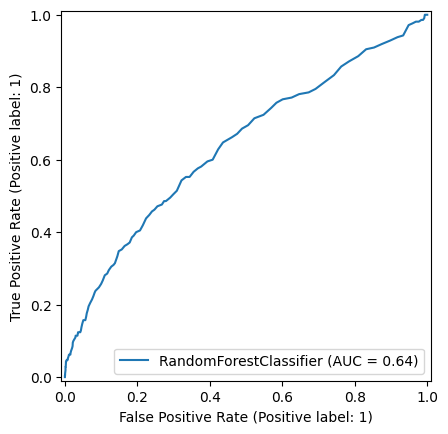

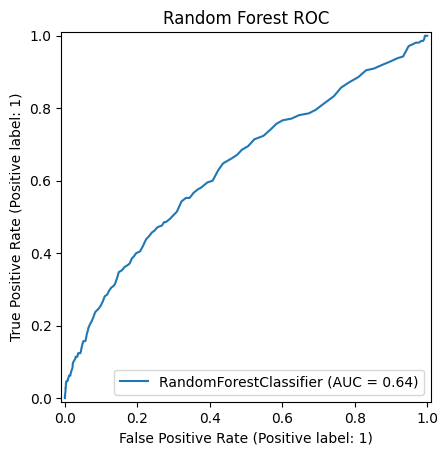

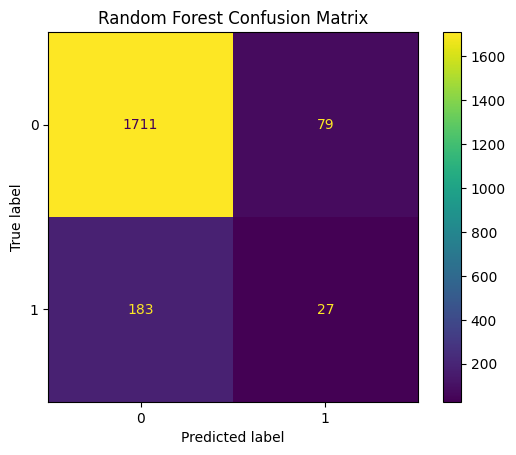

In [ ]:
param_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_rf, cv=3, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train_bal)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
print("Random Forest Report\n", classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:,1]))
RocCurveDisplay.from_estimator(best_rf, X_test_scaled, y_test).plot()
plt.title("Random Forest ROC")
plt.show()
ConfusionMatrixDisplay.from_estimator(best_rf, X_test_scaled, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

**Neural Network**

MLP Report
               precision    recall  f1-score   support

           0       0.90      0.89      0.89      1790
           1       0.15      0.17      0.16       210

    accuracy                           0.81      2000
   macro avg       0.53      0.53      0.53      2000
weighted avg       0.82      0.81      0.82      2000

ROC AUC: 0.5484463953179037


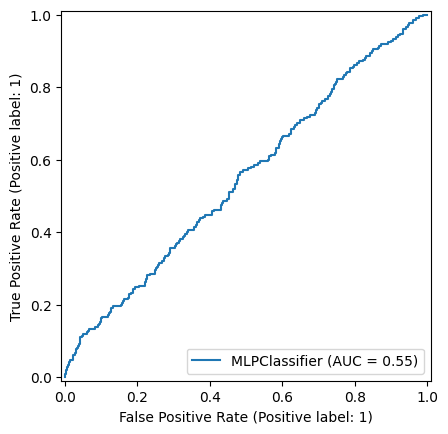

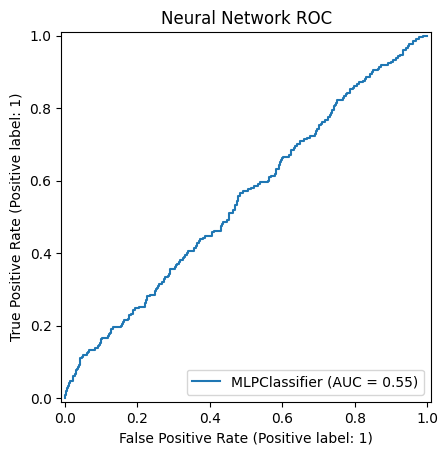

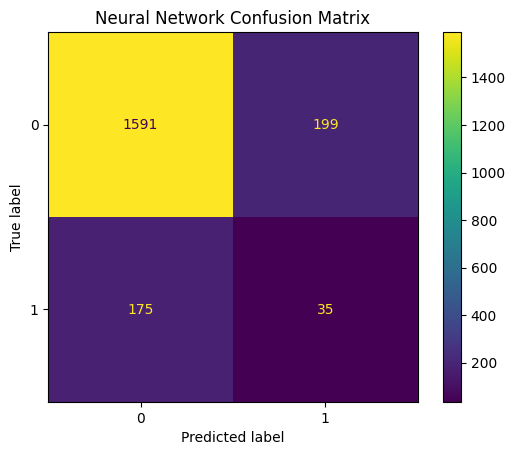

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train_bal)
y_pred_mlp = mlp.predict(X_test_scaled)
print("MLP Report\n", classification_report(y_test, y_pred_mlp))
print("ROC AUC:", roc_auc_score(y_test, mlp.predict_proba(X_test_scaled)[:,1]))
RocCurveDisplay.from_estimator(mlp, X_test_scaled, y_test).plot()
plt.title("Neural Network ROC")
plt.show()
ConfusionMatrixDisplay.from_estimator(mlp, X_test_scaled, y_test)
plt.title("Neural Network Confusion Matrix")
plt.show()

**Final Comparison**

/tmp/ipython-input-14-169471191.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(roc_scores.keys()), y=list(roc_scores.values()), palette="mako")


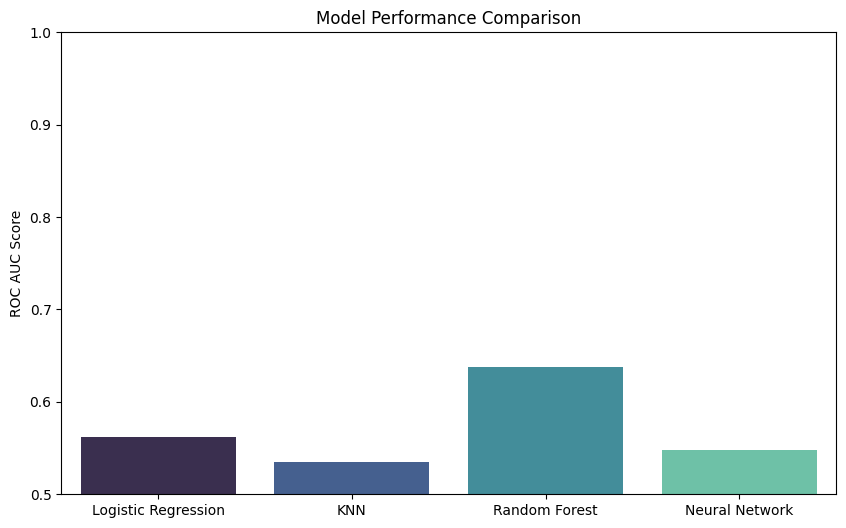

In [ ]:
models = {
    "Logistic Regression": best_lr,
    "KNN": best_knn,
    "Random Forest": best_rf,
    "Neural Network": mlp
}
roc_scores = {name: roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]) for name, model in models.items()}
plt.figure(figsize=(10,6))
sns.barplot(x=list(roc_scores.keys()), y=list(roc_scores.values()), palette="mako")
plt.ylabel("ROC AUC Score")
plt.ylim(0.5, 1.0)
plt.title("Model Performance Comparison")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import pandas as pd

# Split data
X = df.drop("Response", axis=1)
y = df["Response"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Initial random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
selected_features = importances[importances > 0.001].index.tolist()
print("Selected features:", len(selected_features))


Selected features: 40


In [ ]:
# Filter only selected features
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# Train with tuned hyperparameters
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)
rf_tuned.fit(X_train_sel, y_train)

# Predict and evaluate
y_pred_proba = rf_tuned.predict_proba(X_test_sel)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Tuned Random Forest ROC AUC:", roc_auc)


Tuned Random Forest ROC AUC: 0.6849295025272679


Best Model: Random Forest
Best ROC AUC Score: 0.6937084330939081


/tmp/ipython-input-17-2333642612.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(model_scores.keys()), y=list(model_scores.values()), palette="viridis")


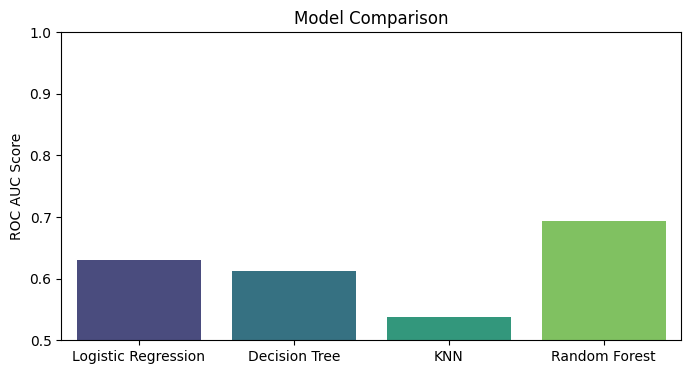

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- LOAD & PREPARE DATA ---
df = pd.read_csv("synthetic_bosch_complex.csv")

# Extract features from datetime
df['test_time'] = pd.to_datetime(df['test_time'])
df['test_hour'] = df['test_time'].dt.hour
df['test_dayofweek'] = df['test_time'].dt.dayofweek
df['test_month'] = df['test_time'].dt.month
df.drop('test_time', axis=1, inplace=True)

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['station', 'product_type', 'shift'], drop_first=True)

# Split into X and y
X = df.drop("Response", axis=1)
y = df["Response"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# --- TRAIN MODELS ---

# Logistic Regression (tuned for convergence)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict_proba(X_test)[:, 1]

# Decision Tree (tuned depth to reduce overfitting)
dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict_proba(X_test)[:, 1]

# KNN (lowered k to reduce bias)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
knn_pred = knn.predict_proba(X_test)[:, 1]

# Random Forest (tuned more trees and limited depth)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]

# --- EVALUATE MODELS ---
model_scores = {
    "Logistic Regression": roc_auc_score(y_test, lr_pred),
    "Decision Tree": roc_auc_score(y_test, dt_pred),
    "KNN": roc_auc_score(y_test, knn_pred),
    "Random Forest": roc_auc_score(y_test, rf_pred),
}

# Print best model
best_model = max(model_scores, key=model_scores.get)
print("Best Model:", best_model)
print("Best ROC AUC Score:", model_scores[best_model])

# Plot comparison
plt.figure(figsize=(8, 4))
sns.barplot(x=list(model_scores.keys()), y=list(model_scores.values()), palette="viridis")
plt.ylabel("ROC AUC Score")
plt.title("Model Comparison")
plt.ylim(0.5, 1.0)
plt.show()
